# BioDYM Material Flow Analysis - Scientific Notebook

A streamlined notebook for Material Flow Analysis using the BioDYM framework with enhanced plotting capabilities. 

## Workflow Overview

This notebook follows a structured approach to Material Flow Analysis:

1. **Setup and Data Loading** - Prepare environment and load input data
2. **Calculation & Validation** - Execute MFA analysis and verify results
3. **Visualization** - Comprehensive analysis and exploration
4. **Scenario & Uncertainty Manager** - (Optional) Compare scenarios and run Monte Carlo analysis
5. **Data Export** - Save results and generate documentation

---

# 1. Setup and Data Loading

This section prepares the analysis environment and loads the input data.

## 1.1 Environment Setup

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from IPython.display import display, HTML, Markdown
import copy

In [ ]:
# Add BioDYM modules to path
src_path = os.path.join(os.getcwd(), '02_src')
sys.path.insert(0, src_path)

In [ ]:
# Add ODYM framework to path
project_root = os.getcwd()
odym_path = os.path.join(
    project_root, "06_framework", "ODYM-master_20241127", "odym", "modules"
)
sys.path.insert(0, odym_path)

In [ ]:
# Add bioDYM add-on to path
biodym_addon_path = os.path.join(
    project_root, "06_framework", "bioDYM_add-on", "modules"
)
sys.path.insert(0, biodym_addon_path)

In [ ]:
# Import BioDYM modules
try:
    import config
    import data_loader
    import system_setup
    import utils
    from engine import solver
    import plotting
    import ODYM_Classes as msc
    print("✅ BioDYM modules imported successfully")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("   Current Python path:")
    for i, path in enumerate(sys.path[:5]):  # Show first 5 paths
        print(f"   {i}: {path}")
    raise

✅ BioDYM modules imported successfully


In [ ]:
# Set up plotting
plt.style.use('default')
print("📊 Plotting environment ready")

📊 Plotting environment ready


## 1.2 Data Input Configuration

In [ ]:
# This is the only manual path setting required.
input_file = "01_data/01_input/251015_BioDYM_DataProtocoll_CS1_Wheat_Straw.xlsm"
print(f"📁 Input file: {input_file}")
if not os.path.exists(input_file):
    raise FileNotFoundError(f"Input file not found: {input_file}")

📁 Input file: 01_data/01_input/251015_BioDYM_DataProtocoll_CS1_Wheat_Straw.xlsm


## 1.3 System Configuration Extraction

In [ ]:
print("\n" + "="*60)
print("⚙️ EXTRACTING CONFIGURATION FROM EXCEL")
print("="*60)


⚙️ EXTRACTING CONFIGURATION FROM EXCEL


In [ ]:
# Load the full dataset once. This will be passed to functions that need it.
input_data = pd.read_excel(
    input_file, sheet_name=None, header=0, engine='openpyxl', na_values=['N.A.', 'NA', 'n/a'], decimal=',')
print(f"✅ Excel file loaded: {len(input_data)} sheets")

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  

✅ Excel file loaded: 19 sheets


c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  

In [ ]:
# Use the robust loader from the config module. This function handles all errors
# and fallbacks, guaranteeing a valid config object is returned.
config_obj = config.load_configuration(input_file)
print("✅ Configuration object loaded.")

✅ Found configuration sheet: '0_Configuration'
✅ Configuration object loaded.


c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [ ]:
# Extract core values from the config object, with fallbacks to data-driven values
try:
    start_year = int(config_obj.Start_Year)
    end_year = int(config_obj.End_Year)
    elements = [elem.strip() for elem in config_obj.Elements.split(',')]
except Exception as e:
    print(f"⚠️ Could not get time/elements from config object: {e}. Falling back to data-driven values.")
    flow_data = input_data['1_2_Data_Flows']
    years = sorted(flow_data['Year_Flow'].unique())
    start_year = int(min(years))
    end_year = int(max(years))
    elements = ['material', 'WC', 'DM', 'CC']

In [ ]:
# Display final configuration summary
run_scenario = getattr(config_obj, 'Run_Scenario_Analysis', False)
selected_scenario = getattr(config_obj, 'Selected_Scenario_Name 1', getattr(config_obj, 'Selected_Scenario_Name', 'N/A'))

In [ ]:
print(f"\n-- Configuration Summary --")
print(f"📅 Time range: {start_year} - {end_year}")
print(f"🧪 Elements: {elements}")
print(f"🎲 Monte Carlo: {'Enabled' if config_obj.RUN_MONTE_CARLO else 'Disabled'}")
print(f"📊 DSM Calculation: {'Enabled' if config_obj.RUN_DSM_CALCULATION else 'Disabled'}")
print(f"🌱 FOMP Calculation: {'Enabled' if config_obj.RUN_FOMP_CALCULATION else 'Disabled'}")
print(f"🎭 Scenario Analysis: {'Enabled' if run_scenario else 'Disabled'}")
if run_scenario:
    print(f"   -> Selected Scenario: '{selected_scenario}'")


-- Configuration Summary --
📅 Time range: 2025 - 2125
🧪 Elements: ['material', 'WC', 'DM', 'CC']
🎲 Monte Carlo: Enabled
📊 DSM Calculation: Disabled
🌱 FOMP Calculation: Enabled
🎭 Scenario Analysis: Disabled


# 2. Calculation and Validation

In [ ]:
# ## 2.1 Model Initialization & Calculation
print("\n" + "="*60)
print("🚀 RUNNING BASELINE MFA CALCULATION")
print("="*60)


🚀 RUNNING BASELINE MFA CALCULATION


In [ ]:
print("📋 Setting up model scope...")
model_classification, index_table = system_setup.define_model_scope(start_year, end_year, elements)

📋 Setting up model scope...
--> Model scope and classifications defined.


In [ ]:
print("🔧 Initializing MFA system...")
mfa_system_base = system_setup.initialize_mfa_system(model_classification, index_table)

🔧 Initializing MFA system...
--> MFA system object initialized.


In [ ]:
print("📊 Loading processes and data...")
mfa_system_base, all_excel_data = system_setup.load_and_define_processes(mfa_system_base, input_data, data_loader)

📊 Loading processes and data...
--> Defining process and stock structures...
--> Validating input data structure...
  -> Using unified configuration columns in '2_1_Definition_Processes'
--> Input data validation successful.
--> Stock values initialized.


In [ ]:
print("🔗 Defining flows and base parameters (e.g., compositions from flowsheet)...")
mfa_system_configured, _, flow_tc_map, process_logic_map = system_setup.define_flows_and_parameters(mfa_system_base, all_excel_data)

🔗 Defining flows and base parameters (e.g., compositions from flowsheet)...
--> Defining flows, parameters, and setting all initial values...
--> All flows initialized to zero.
--> Populated data for primary input flows.
--> Loading initial stock parameters from sheet '2_4_Initial_Stock'...
--> Successfully loaded initial stock configurations for 0 process(es).
--> Creating Flow-to-TC mapping...


In [ ]:
print("⚙️ Loading all model parameters (TCs, DSM, FOMP)...")

⚙️ Loading all model parameters (TCs, DSM, FOMP)...


In [ ]:
# Centralized call to the new, unified TC loader
time_vector = mfa_system_configured.IndexTable.Classification['Time'].Items
elements_list = mfa_system_configured.Elements
tc_params = data_loader.load_tc_parameters(all_excel_data, elements_list, time_vector)
mfa_system_configured.ParameterDict.update(tc_params) # Add the new TC params to the system

--> Loading Transfer Coefficients using unified TC_Configuration...
--> INFO: Process 0 (Pass-through) - skipping TCs (process type)
--> INFO: Process 1 (Pass-through) - skipping TCs (process type)
--> INFO: Process 11 (Input) - skipping TCs (process type)
  -> Processing static TCs for 7 processes...
    -> Loaded static TC: TC_material_03_04 = 0.53
    -> Loaded static TC: TC_material_03_05 = 0.47
    -> Loaded static TC: TC_material_05_06 = 0.3333333333333333
    -> Loaded static TC: TC_material_05_12 = 0.3333333333333333
    -> Loaded static TC: TC_material_05_09 = 0.3333333333333333
    -> Loaded static TC: TC_WC_04_00 = 0.0
    -> Loaded static TC: TC_DM_04_00 = 0.48000000000000004
    -> Loaded static TC: TC_CC_04_00 = 1.0
    -> Loaded static TC: TC_WC_04_01 = 1.0
    -> Loaded static TC: TC_DM_04_01 = 0.5200000000000001
    -> Loaded static TC: TC_CC_04_01 = 0.0
    -> Loaded static TC: TC_WC_12_00 = 0.0
    -> Loaded static TC: TC_DM_12_00 = 0.31197674418604654
    -> Loaded 

In [ ]:
# Load other special model parameters
dsm_params = data_loader.load_dsm_parameters(all_excel_data)
if config_obj.RUN_FOMP_CALCULATION:
    fomp_params = data_loader.load_fomp_parameters(all_excel_data)
else:
    fomp_params = {}
uncertainty_params = data_loader.load_uncertainty_definitions(all_excel_data)

--> Loading DSM parameters from sheet '3_1_Definition_DSM'...
--> Using Process_Logic column from main sheet to identify DSM processes: []
--> INFO: No DSM processes found in main sheet.
--> Loading FOMP parameters from sheet '3_2_Definition_FOMP'...
--> Successfully loaded configurations for 4 FOMP process(es).
   Process 8: 6 parameters
   Process 10: 6 parameters
   Process 7: 6 parameters
   Process 13: 1 parameters
--> Loading uncertainty definitions from sheet '4_1_Uncertainty_Parameters'...
  DEBUG: df_uncertainty before dropna:
    ID          MC_Parameter                    Parameter_Selection  \
0    1  List_FOMP_Parameters        Inflow_fraction_f (Labile pool)   
1    2  List_FOMP_Parameters                 decay_k1 (Labile pool)   
2    3  List_FOMP_Parameters  Inflow_fraction_f (Recalcitrant pool)   
3    4  List_FOMP_Parameters           decay_k2 (Recalcitrant pool)   
4    5  List_FOMP_Parameters        Inflow_fraction_f (Labile pool)   
5    6  List_FOMP_Parameters    

In [ ]:
print("✅ All parameters loaded and configured.")

✅ All parameters loaded and configured.


In [ ]:
print("🧮 Running baseline calculation...")
mfa_results_baseline, dsm_details_baseline = solver.run_mfa_calculation(mfa_system_configured, dsm_params, fomp_params, config_obj, flow_tc_map=flow_tc_map, process_logic_map=process_logic_map)
print("✅ Baseline calculation completed successfully!")

🧮 Running baseline calculation...
   FOMP Process 8 - Input Flow Composition:
     DM fraction: 0.860 (range: 0.860 - 0.860)
     CC fraction: 0.413 (range: 0.413 - 0.413)
     WC fraction: 0.140 (range: 0.140 - 0.140)
   Total carbon output: 5414908.05
   Total environmental output: 5866150.40
   FOMP Process 10 - Input Flow Composition:
     DM fraction: 0.674 (range: 0.641 - 0.693)
     CC fraction: 0.349 (range: 0.332 - 0.359)
     WC fraction: 0.326 (range: 0.307 - 0.359)
   Total carbon output: 2296782.18
   Total environmental output: 2133739.00
   FOMP Process 7 - Input Flow Composition:
     DM fraction: 1.000 (range: 1.000 - 1.000)
     CC fraction: 1.000 (range: 1.000 - 1.000)
     WC fraction: nan (range: 0.000 - 0.000)
   Total carbon output: 237058.78
   Total environmental output: 0.00
   FOMP Process 8 - Input Flow Composition:
     DM fraction: 0.860 (range: 0.860 - 0.860)
     CC fraction: 0.413 (range: 0.413 - 0.413)
     WC fraction: 0.140 (range: 0.140 - 0.140)
   

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## 2.2 Mass Balance Validation

In [ ]:
print("\n" + "="*60)
print("⚖️ MASS BALANCE VERIFICATION (BASELINE)")
print("="*60)
plotting.plot_total_mass_balance_error(mfa_results_baseline)
plotting.plot_optimized_mass_balance_error(mfa_results_baseline)


⚖️ MASS BALANCE VERIFICATION (BASELINE)


interactive(children=(IntSlider(value=2025, description='Year', max=2125, min=2025), Dropdown(description='Ele…

FigureWidget({
    'data': [{'hovertemplate': '<b>%{x}</b><br>Error: %{y:.2e} Mg<extra></extra>',
              'marker': {'color': [#00C851, #00C851, #00C851, #00C851, #00C851,
                                   #00C851, #00C851, #00C851, #00C851, #00C851,
                                   #00C851, #00C851, #00C851],
                         'line': {'color': '#212529', 'width': 1}},
              'type': 'bar',
              'uid': 'a042e570-8f59-4030-bd37-a2635f505b0e',
              'x': [Atmosphere, Environment, Cultivation, Harvest, Grain
                    Processing & Consumption, Straw Collection & Distribution,
                    Direct Incorporation, Lithosphere (P&I), Lithosphere (I),
                    Composting & Incorporation, Lithosphere (C&I),
                    Water_Composting, Pyrolysis],
              'y': [0.0, 0.0, 0.0, 0.0, 5.820766091346741e-11, 0.0, 0.0, 0.0, 0.0,
                    0.0, 0.0, 0.0, -1.4551915228366852e-11]}],
    'layout': {'font': {'col


--- System Flow Diagram (Graphviz) ---
🔍 Graphviz Analysis:
   Input: 46 processes, 69 flows
   Data Quality Check:
   - Complete processes: 13/46
   - Complete flows: 24/69
   - Connected processes: 13
   Final: 13 processes, 24 flows
   ✅ Graphviz chart created successfully!


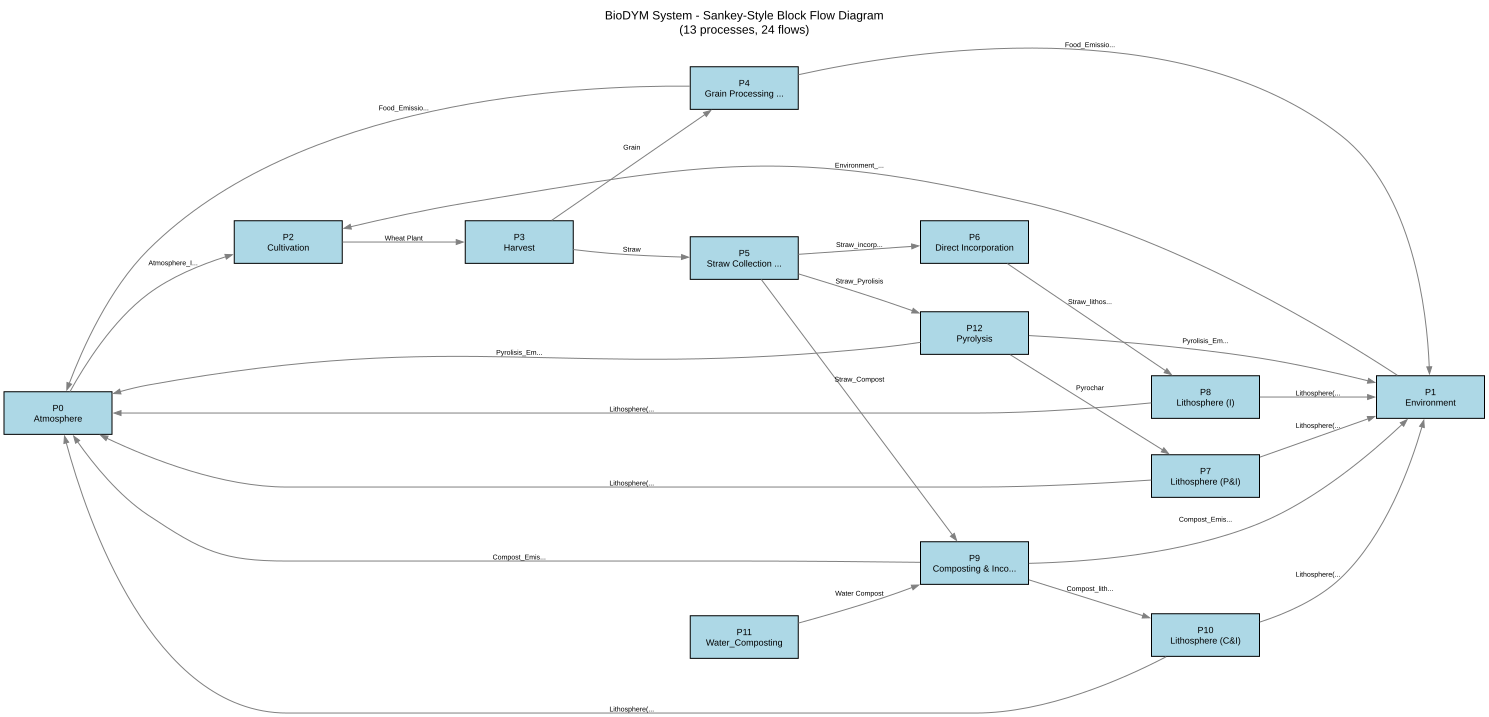

✅ Graphviz chart created successfully!


In [ ]:
# ## 2.3 System Flow Diagram (Graphviz)
print("\n--- System Flow Diagram (Graphviz) ---")
try:
    from plotting.graphviz_flow_charts import plot_graphviz_flow_chart_sankey_style
    
    # Get the required dataframes from the loaded data
    processes_data = all_excel_data['2_1_Definition_Processes']
    flows_data = all_excel_data['1_1_Definition_Flows']
    
    # Generate and display the chart
    dot_chart = plot_graphviz_flow_chart_sankey_style(processes_data, flows_data)
    if dot_chart:
        display(dot_chart)
        print("✅ Graphviz chart created successfully!")
except ImportError:
    print("⚠️ Graphviz library not found. Skipping this plot.")
except Exception as e:
    print(f"⚠️ Graphviz chart failed: {e}")

# 3. Visualization

In [ ]:
print("\n" + "="*60)
print("📊 VISUALIZATION (BASELINE)")
print("="*60)


📊 VISUALIZATION (BASELINE)


In [ ]:
# ## 3.1 Traditional Sankey Diagram
print("\n--- Traditional Sankey Diagram ---")
plotting.plot_interactive_sankey(mfa_results_baseline, dsm_params, fomp_params)


--- Traditional Sankey Diagram ---


FigureWidget({
    'data': [{'arrangement': 'snap',
              'link': {'color': [#00C851, #00C851, #00C851, #00C851, #00C851,
                                 #00C851, #00C851, #00C851, #00C851, #00C851,
                                 #00C851, #00C851, #00C851, #00C851, #00C851,
                                 #00C851, #00C851, #00C851, #00C851, #00C851,
                                 #00C851, #00C851, #00C851, #00C851],
                       'customdata': [Atmosphere_Input_C, Environment_Input_E,
                                      Wheat Plant, Grain, Straw, Food_Emissions_C,
                                      Food_Emissions_E, Straw_incorperation,
                                      Straw_lithosphere, Straw_Pyrolisis,
                                      Pyrolisis_Emissions_C, Pyrolisis_Emissions_E,
                                      Lithosphere(I)_Emissions_C,
                                      Lithosphere(I)_Emissions_E, Straw_Compost,
                      

In [ ]:
# ## 3.2 Enhanced Sankey Diagram
print("\n--- Enhanced Sankey Diagram ---")
try:
    from plotting.enhanced_sankey import plot_enhanced_sankey
    print("🎯 Creating enhanced Sankey diagram...")
    plot_enhanced_sankey(
        mfa_system_results=mfa_results_baseline,
        dsm_params=dsm_params,
        fomp_params=fomp_params,
        visualization_config_path=input_file
    )
    print("✅ Enhanced Sankey diagram created successfully!")
except Exception as e:
    print(f"⚠️ Enhanced Sankey diagram failed: {e}")
    import traceback
    traceback.print_exc()


--- Enhanced Sankey Diagram ---
🎯 Creating enhanced Sankey diagram...
Loading visualization configuration from Excel...
  Loaded and processed 6_1_Visualization_Processes
  Loaded 6_2_Visualization_Flows
  Loaded 6_3_Layout_Configuration
Visualization configuration loaded successfully


✅ Enhanced Sankey diagram created successfully!


In [ ]:
# ## 3.3 Additional Visualizations
print("\n--- Additional Visualizations ---")


--- Additional Visualizations ---


In [ ]:
# ### 3.3.1 Core System Dynamics
print("\n📊 Core System Dynamics:")
print("   • Process Dynamics: Interactive 3-panel view (Inflow/Stock/Outflow)")
print("   • Flow Dynamics: Multi-flow time series analysis")
print("   • Stock Analysis: Interactive bar charts with time slider")


📊 Core System Dynamics:
   • Process Dynamics: Interactive 3-panel view (Inflow/Stock/Outflow)
   • Flow Dynamics: Multi-flow time series analysis
   • Stock Analysis: Interactive bar charts with time slider


In [ ]:
# Process Dynamics - 3-panel view showing inflow, stock, and outflow for selected processes
print("\n🔄 Process Dynamics Analysis:")
plotting.plot_process_dynamics(mfa_results_baseline, all_excel_data['2_1_Definition_Processes'])


🔄 Process Dynamics Analysis:


interactive(children=(Dropdown(description='Process:', options=('Atmosphere', 'Environment', 'Cultivation', 'H…

FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'Inflow',
              'type': 'scatter',
              'uid': '78724afb-ec2f-482a-8c63-968f5b1bd93f',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050, 2051, 2052, 2053, 2054,
                    2055, 2056, 2057, 2058, 2059, 2060, 2061, 2062, 2063, 2064,
                    2065, 2066, 2067, 2068, 2069, 2070, 2071, 2072, 2073, 2074,
                    2075, 2076, 2077, 2078, 2079, 2080, 2081, 2082, 2083, 2084,
                    2085, 2086, 2087, 2088, 2089, 2090, 2091, 2092, 2093, 2094,
                    2095, 2096, 2097, 2098, 2099, 2100, 2101, 2102, 2103, 2104,
                    2105, 2106, 2107, 2108, 2109, 2110, 2111, 2112, 2113, 2114,
                    2115, 2116, 2117, 2118, 2119, 2120, 2121, 2122, 2123, 2124,
                    2125],
 

In [ ]:
# Flow Dynamics - Multi-flow time series with element selection
print("\n🌊 Flow Dynamics Analysis:")
plotting.plot_flow_dynamics(mfa_results_baseline)


🌊 Flow Dynamics Analysis:


interactive(children=(SelectMultiple(description='Flows:', index=(0,), options=('Atmosphere_Input_C', 'Environ…

FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'Atmosphere_Input_C',
              'type': 'scatter',
              'uid': '715a5a09-72aa-43ea-8a38-0b55e7b198fa',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050, 2051, 2052, 2053, 2054,
                    2055, 2056, 2057, 2058, 2059, 2060, 2061, 2062, 2063, 2064,
                    2065, 2066, 2067, 2068, 2069, 2070, 2071, 2072, 2073, 2074,
                    2075, 2076, 2077, 2078, 2079, 2080, 2081, 2082, 2083, 2084,
                    2085, 2086, 2087, 2088, 2089, 2090, 2091, 2092, 2093, 2094,
                    2095, 2096, 2097, 2098, 2099, 2100, 2101, 2102, 2103, 2104,
                    2105, 2106, 2107, 2108, 2109, 2110, 2111, 2112, 2113, 2114,
                    2115, 2116, 2117, 2118, 2119, 2120, 2121, 2122, 2123, 2124,
                

In [ ]:
# Stock Bar Chart - Interactive stock levels with time slider
print("\n📈 Stock Levels Analysis:")
plotting.plot_stock_bar_chart(mfa_results_baseline, title="Stock Levels Over Time (Baseline)")


📈 Stock Levels Analysis:


interactive(children=(IntSlider(value=2025, description='Year', max=2125, min=2025), Dropdown(description='Ele…

FigureWidget({
    'data': [{'hovertemplate': '<b>%{x}</b><br>Stock: %{y:.2f} Mg<extra></extra>',
              'marker': {'color': ['#2ca02c', '#2ca02c', '#2ca02c', '#2ca02c', '#2ca02c', '#2ca02c']},
              'type': 'bar',
              'uid': '958d7ab2-90c0-4804-800b-9c3bff87f18f',
              'x': array(['Atmosphere', 'Environment', 'Lithosphere (P&I)', 'Lithosphere (I)',
                          'Lithosphere (C&I)', 'Water_Composting'], dtype=object),
              'y': array([0., 0., 0., 0., 0., 0.])}],
    'layout': {'font': {'color': '#212529', 'family': 'Arial, sans-serif', 'size': 10},
               'height': 800,
               'legend': {'bgcolor': 'rgba(255,255,255,0.8)',
                          'bordercolor': '#6C757D',
                          'borderwidth': 1,
                          'font': {'color': '#212529', 'family': 'Arial, sans-serif', 'size': 10}},
               'margin': {'b': 100, 'l': 100, 'r': 50, 't': 100},
               'paper_bgcolor': '#F

In [ ]:
# System Stock Composition - Individual process stocks over time
print("\n🏗️ Individual Process Stocks Analysis:")
print("   • Individual process stocks over time")
print("   • Shows each process stock separately")
print("   • Element selection and bar/line chart options")
plotting.plot_system_stock_composition(mfa_results_baseline)


🏗️ Individual Process Stocks Analysis:
   • Individual process stocks over time
   • Shows each process stock separately
   • Element selection and bar/line chart options


FigureWidget({
    'data': [], 'layout': {'template': '...'}
})

In [ ]:
# ### 3.3.2 Specialized Process Analysis (if applicable)
print("\n📊 Specialized Process Analysis:")


📊 Specialized Process Analysis:


In [ ]:
# DSM Stock Details - Detailed DSM stock evolution (if DSM processes exist)
if dsm_params and dsm_details_baseline:
    print("\n🏗️ DSM Stock Evolution Analysis:")
    print("   • Individual and cumulative stock views")
    print("   • Lifetime analysis and category breakdown")
    plotting.plot_dsm_stock_details(mfa_results_baseline, dsm_params, dsm_details_baseline)
    
    print("\n🔄 DSM Process Dynamics Analysis:")
    print("   • Three-panel view: Input, Stock, Output")
    print("   • Stacked flows by element (Material, WC, DM, CC)")
    print("   • Dynamic material composition for DSM processes")
    plotting.plot_dsm_process_dynamics(mfa_results_baseline, dsm_params, dsm_details_baseline)
else:
    print("   ℹ️ No DSM processes found - skipping DSM analysis")

   ℹ️ No DSM processes found - skipping DSM analysis


In [ ]:
# FOMP Analysis - FOMP mineralization analysis (if FOMP processes exist)
if fomp_params:
    print("\n🌱 FOMP Mineralization Analysis:")
    print("   • Organic matter accumulation and mineralization")
    print("   • Annual vs cumulative flow analysis")
    plotting.plot_fomp_stock_details(mfa_results_baseline, fomp_params)
    
    # FOMP Process Dynamics - Three-panel view of FOMP processes
    print("\n🔄 FOMP Process Dynamics:")
    print("   • Three panels: Input Flows (DM), Stock Evolution (DM), Mineralization Output (DM)")
    print("   • Decay rates displayed as percentages")
    print("   • Water Content (WC) excluded from mineralization")
    plotting.plot_fomp_dynamics(mfa_results_baseline, fomp_params)
else:
    print("   ℹ️ No FOMP processes found - skipping FOMP analysis")


🌱 FOMP Mineralization Analysis:
   • Organic matter accumulation and mineralization
   • Annual vs cumulative flow analysis


FigureWidget({
    'data': [{'hovertemplate': '<b>Stock</b><br>Year: %{x}<br>Mass: %{y:.2f} Mg<extra></extra>',
              'line': {'color': '#2ca02c', 'width': 3},
              'marker': {'size': 4},
              'mode': 'lines+markers',
              'name': 'Organic Matter Stock',
              'type': 'scatter',
              'uid': '87e962e2-8f84-4bba-a5ed-b4b8afba2427',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050, 2051, 2052, 2053, 2054,
                    2055, 2056, 2057, 2058, 2059, 2060, 2061, 2062, 2063, 2064,
                    2065, 2066, 2067, 2068, 2069, 2070, 2071, 2072, 2073, 2074,
                    2075, 2076, 2077, 2078, 2079, 2080, 2081, 2082, 2083, 2084,
                    2085, 2086, 2087, 2088, 2089, 2090, 2091, 2092, 2093, 2094,
                    2095, 2096, 2097, 2098, 2099, 2100, 


🔄 FOMP Process Dynamics:
   • Three panels: Input Flows (DM), Stock Evolution (DM), Mineralization Output (DM)
   • Decay rates displayed as percentages
   • Water Content (WC) excluded from mineralization


# 4. Scenario & Uncertainty Manager

In [ ]:
# ## 4.1 Scenario Analysis & Comparison
print("\n" + "="*60)
print("🎭 SCENARIO ANALYSIS")
print("="*60)


🎭 SCENARIO ANALYSIS


In [ ]:
# Import the new scenario engine
from engine import scenario_engine

In [ ]:
# Run scenario analysis using the new engine
all_scenario_results, scenario_definitions = scenario_engine.run_scenario_analysis(
    config_obj=config_obj,
    mfa_system_configured=mfa_system_configured,
    all_excel_data=all_excel_data,
    dsm_params=dsm_params,
    fomp_params=fomp_params,
    flow_tc_map=flow_tc_map,
    process_logic_map=process_logic_map
)


🎭 SCENARIO ANALYSIS ENGINE
ℹ️ Scenario analysis is disabled in configuration.


In [ ]:
# Generate visualizations if scenarios were run
if all_scenario_results:
    scenario_engine.generate_scenario_comparison_visualizations(
        baseline_results=mfa_results_baseline,
        all_scenario_results=all_scenario_results,
        scenario_definitions=scenario_definitions
    )
    
    # Export scenario results
    scenario_engine.export_scenario_results(
        all_scenario_results=all_scenario_results,
        scenario_definitions=scenario_definitions
    )
else:
    print("ℹ️ No scenarios were processed.")

ℹ️ No scenarios were processed.


In [ ]:
# ## 4.2 Monte Carlo Analysis
print("\n" + "="*60)
print("🎲 MONTE CARLO SIMULATION (BASELINE)")
print("="*60)


🎲 MONTE CARLO SIMULATION (BASELINE)


In [ ]:
if config_obj.RUN_MONTE_CARLO and '4_1_Uncertainty_Parameters' in input_data:
    try:
        from engine.mc_simulation import run_mc_simulation
        from plotting.monte_carlo import (
            plot_interactive_mc_multiple_histograms,
            plot_interactive_tornado, 
            plot_interactive_mc_paths, 
            plot_interactive_mc_stock_comparison
        )
        
        mc_results = run_mc_simulation(
            mfa_system_configured, 
            input_data, 
            dsm_params, 
            fomp_params, 
            config_obj, 
            process_logic_map=process_logic_map, 
            flow_tc_map=flow_tc_map
        )
        
        if mc_results is not None and not mc_results.empty:
            print("✅ Monte Carlo simulation completed for baseline.")

            # --- Export MC Results ---
            print("\n💾 Exporting Monte Carlo results...")
            from datetime import datetime
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            mc_output_path = f"01_data/02_output/mc_output/mc_results_detailed_{timestamp}.xlsx"
            try:
                mc_results.to_excel(mc_output_path, index=False)
                print(f"✅ Monte Carlo results successfully exported to: {mc_output_path}")
            except Exception as export_error:
                print(f"⚠️ Could not export Monte Carlo results: {export_error}")
            # -------------------------

            print("\n📊 Monte Carlo Analysis Visualizations:")
            print("   • Multiple Distribution Histograms: Interactively select and view histograms for multiple stocks.")
            print("   • Sensitivity Tornado Plot: Identify which parameters most influence outcomes.")
            print("   • Simulation Paths: Visualize the trajectories of all Monte Carlo runs.")
            print("   • Stock Comparison: Compare distributions of several stocks in one plot.")

            # This new function allows selecting multiple histograms, making the old single one redundant.
            plot_interactive_mc_multiple_histograms(mc_results, mfa_results_baseline)
            
            plot_interactive_tornado(mc_results)
            plot_interactive_mc_paths(mc_results, mfa_results_baseline)
            plot_interactive_mc_stock_comparison(mc_results, mfa_results_baseline)
            
    except Exception as e:
        print(f"⚠️ Monte Carlo simulation failed: {e}")
        import traceback
        traceback.print_exc()
else:
    print("ℹ️ Monte Carlo analysis is disabled or no uncertainty parameters are defined. Skipping.")

--> Loading uncertainty definitions from sheet '4_1_Uncertainty_Parameters'...
  DEBUG: df_uncertainty before dropna:
    ID          MC_Parameter                    Parameter_Selection  \
0    1  List_FOMP_Parameters        Inflow_fraction_f (Labile pool)   
1    2  List_FOMP_Parameters                 decay_k1 (Labile pool)   
2    3  List_FOMP_Parameters  Inflow_fraction_f (Recalcitrant pool)   
3    4  List_FOMP_Parameters           decay_k2 (Recalcitrant pool)   
4    5  List_FOMP_Parameters        Inflow_fraction_f (Labile pool)   
5    6  List_FOMP_Parameters                 decay_k1 (Labile pool)   
6    7  List_FOMP_Parameters  Inflow_fraction_f (Recalcitrant pool)   
7    8  List_FOMP_Parameters           decay_k2 (Recalcitrant pool)   
8    9  List_FOMP_Parameters        Inflow_fraction_f (Labile pool)   
9   10  List_FOMP_Parameters                 decay_k1 (Labile pool)   
10  11  List_FOMP_Parameters  Inflow_fraction_f (Recalcitrant pool)   
11  12  List_FOMP_Parameters  

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning:

Mean of empty slice.

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning:

invalid value encountered in scalar divide



   Total carbon output: 2029313.11
   Total environmental output: 1885256.94
   FOMP Process 7 - Input Flow Composition:
     DM fraction: 1.000 (range: 1.000 - 1.000)
     CC fraction: 1.000 (range: 1.000 - 1.000)
     WC fraction: nan (range: 0.000 - 0.000)
   Total carbon output: 255801.10
   Total environmental output: 0.00
--> System converged after 2 iterations.
--> Calculating final stock balances for ALL processes...
--> Stock balance calculation finished.
   Applied MC sample: P08_decay_k1 (Labile pool) = 0.5994 to Process 8
   Applied MC sample: P08_decay_k2 (Recalcitrant pool) = 0.0277 to Process 8
   Applied MC sample: P10_decay_k1 (Labile pool) = 0.4262 to Process 10
   Applied MC sample: P10_decay_k2 (Recalcitrant pool) = 0.0231 to Process 10
   Applied MC sample: P07_decay_k1 (Labile pool) = 0.4478 to Process 7
   Applied MC sample: P07_decay_k2 (Recalcitrant pool) = 0.0019 to Process 7
   FOMP Process 8 - Input Flow Composition:
     DM fraction: 0.860 (range: 0.860 - 0

# 5. Data Export

In [ ]:
print("\n" + "="*60)
print("💾 EXPORTING BASELINE RESULTS")
print("="*60)


💾 EXPORTING BASELINE RESULTS


In [ ]:
output_file = "01_data/02_output/results_scientific_baseline.xlsx"
utils.export_results_to_excel(mfa_results_baseline, output_file, input_file_path=input_file)
print(f"✅ Baseline results exported to: {output_file}")

--> Exporting results to '01_data/02_output/results_scientific_baseline.xlsx'...
✅ Results successfully exported to 01_data/02_output/results_scientific_baseline.xlsx
✅ Baseline results exported to: 01_data/02_output/results_scientific_baseline.xlsx


In [ ]:
print("\n" + "="*60)
print("🎉 ANALYSIS COMPLETE")
print("="*60)


🎉 ANALYSIS COMPLETE
